# EmotionCLIP-ReID RAF-DB Runbook

Notebook này dùng RAF-DB Basic, tạo landmark offline một lần và lưu mỗi lần train vào một `RUN_ID` có ngày giờ. Official train được tách validation xác định; official test luôn sealed test và không tham gia chọn checkpoint.


## 0. Clone hoặc cập nhật đúng branch `old_branch`

Máy mới dùng `git clone -b old_branch --single-branch`; repo có sẵn sẽ được fetch, checkout và fast-forward đúng branch trước khi chạy.


In [10]:
from pathlib import Path
import os
import subprocess
import sys

JUPYTER_WORKSPACE = Path('/home/jupyter-hault')
REPO_DIR = JUPYTER_WORKSPACE / 'EmotionCLIP-ReID'
GIT_REPO_URL = 'https://github.com/haulth/EmotionCLIP-ReID.git'
REPO_BRANCH = 'old_branch'

JUPYTER_WORKSPACE.mkdir(parents=True, exist_ok=True)
if (REPO_DIR / '.git').exists():
    commands = [
        ['git', '-C', str(REPO_DIR), 'fetch', 'origin', REPO_BRANCH],
        ['git', '-C', str(REPO_DIR), 'checkout', REPO_BRANCH],
        ['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', REPO_BRANCH],
    ]
else:
    commands = [[
        'git', 'clone', '-b', REPO_BRANCH, '--single-branch', GIT_REPO_URL, str(REPO_DIR)
    ]]
for command in commands:
    print('Running:', ' '.join(command))
    completed = subprocess.run(command, text=True, capture_output=True, check=True)
    if completed.stdout.strip():
        print(completed.stdout.strip())

REPO = REPO_DIR.resolve()
os.chdir(REPO)
branch = subprocess.check_output(['git', '-C', str(REPO), 'branch', '--show-current'], text=True).strip()
assert branch == REPO_BRANCH, f'Expected {REPO_BRANCH}, got {branch}'
print('Repo:', REPO)
print('Branch:', branch)
print('Python:', sys.executable)


Running: git -C /home/jupyter-hault/EmotionCLIP-ReID fetch origin old_branch
Running: git -C /home/jupyter-hault/EmotionCLIP-ReID checkout old_branch
Your branch is behind 'origin/old_branch' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
Running: git -C /home/jupyter-hault/EmotionCLIP-ReID pull --ff-only origin old_branch
Updating 8e1ad5dc..8cd65b47
Fast-forward
 config/emotion_defaults.py                         |  14 +-
 .../emotion/vit_b16_emotionclip_fer2013_quick.yml  |  21 +-
 .../vit_b16_emotionclip_hf_fer2013_quick.yml       |  21 +-
 .../emotion/vit_b16_emotionclip_rafdb_quick.yml    |  13 +-
 note_edit.md                                       |  49 ++
 ...otionclip_reid_jupyterhub_build_landmarks.ipynb | 603 ++-------------------
 .../emotionclip_reid_jupyterhub_fer2013.ipynb      |  38 +-
 notebooks/emotionclip_reid_jupyterhub_rafdb.ipynb  | 224 +++++++-
 processor/processor_emotionclip.py                 | 140 ++++-
 tests/test_emoti

## 1. Kiểm tra package tối thiểu

In [11]:
import importlib.util
import subprocess
import sys

required = ["torch", "PIL", "yaml", "numpy","kaggle"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
print("Missing:", missing)
if missing:
    print("Cài environment theo environment_emotionclip_cuda.yml hoặc cài các package còn thiếu trước khi train.")

# Kaggle chỉ cần nếu bạn muốn tải bằng Kaggle thay vì upload archive RAF-DB sẵn.
print("Kaggle module:", importlib.util.find_spec("kaggle") is not None)

Missing: []
Kaggle module: True


## 2. Process RAF-DB đã có sẵn

Notebook dùng trực tiếp path `RAFDB_DATA_DIR` khai báo ở cell dưới. `manifest.jsonl`, `manifest_anatomy.jsonl` và thư mục `anatomy_v3/` phải cùng nằm trong thư mục dataset này. Converter tạo validation xác định từ official train và giữ official test làm test sealed; không remap official test thành validation.


In [12]:
from pathlib import Path
import subprocess
import sys
REPO = Path(REPO).resolve()

# ===== PATH RAF-DB CHỈNH TRỰC TIẾP TẠI ĐÂY =====
RAFDB_DATA_DIR = (REPO / 'data' / 'RAF-DB').resolve()
RAFDB_MANIFEST = RAFDB_DATA_DIR / 'manifest.jsonl'
RAFDB_ANATOMY_MANIFEST = RAFDB_DATA_DIR / 'manifest_anatomy.jsonl'
RAFDB_ANATOMY_DIR = RAFDB_DATA_DIR / 'anatomy_v3'
RAF_ROOT = RAFDB_DATA_DIR
RAF_MANIFEST = RAFDB_MANIFEST

if not RAF_ROOT.exists():
    raise FileNotFoundError(f"Không thấy RAF-DB tại {RAF_ROOT}")
for required in ["train_labels.csv", "test_labels.csv"]:
    if not (RAF_ROOT / required).exists():
        raise FileNotFoundError(f"Thiếu {RAF_ROOT / required}")

convert_cmd = [
    sys.executable,
    "tools/convert_rafdb_to_emotion_jsonl.py",
    "--raf-root",
    str(RAF_ROOT),
    "--output",
    str(RAF_MANIFEST),
    "--root-dir",
    str(RAF_ROOT),
]
print("Converting existing data/RAF-DB -> EmotionCLIP manifest")
subprocess.run(convert_cmd, cwd=REPO, check=True)
print('RAFDB_DATA_DIR:', RAFDB_DATA_DIR)
print('RAFDB_MANIFEST:', RAFDB_MANIFEST)
print('RAFDB_ANATOMY_MANIFEST:', RAFDB_ANATOMY_MANIFEST)
print('RAFDB_ANATOMY_DIR:', RAFDB_ANATOMY_DIR)


Converting existing data/RAF-DB -> EmotionCLIP manifest
Wrote 15339 RAF-DB records to /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl
Split protocol: deterministic class-stratified validation from official train; official test remains sealed.
Validation ratio: 0.2; split seed: 1234
ROOT_DIR for training: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB
Label files: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/train_labels.csv, /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/test_labels.csv
train: 9818
  anger: 564
  disgust: 574
  fear: 225
  happiness: 3818
  sadness: 1586
  surprise: 1032
  neutral: 2019
val: 2453
  anger: 141
  disgust: 143
  fear: 56
  happiness: 954
  sadness: 396
  surprise: 258
  neutral: 505
test: 3068
  anger: 162
  disgust: 160
  fear: 74
  happiness: 1185
  sadness: 478
  surprise: 329
  neutral: 680
RAFDB_DATA_DIR: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB
RAFDB_MANIFEST: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.

## 3. Kiểm tra manifest và phân bố split

In [13]:
import json
from collections import Counter

assert RAF_MANIFEST.exists(), f"Missing manifest: {RAF_MANIFEST}"
records = [json.loads(line) for line in RAF_MANIFEST.read_text(encoding="utf-8").splitlines() if line.strip()]
print("Total records:", len(records))
print("Split counts:", Counter(record["split"] for record in records))
print("Official split counts:", Counter(record.get("official_split") for record in records))
print("Emotion counts:", Counter(record["emotion"] for record in records))
print("Split protocol:", records[0].get("split_protocol"))
records[:3]

Total records: 15339
Split counts: Counter({'train': 9818, 'test': 3068, 'val': 2453})
Official split counts: Counter({'train': 12271, 'test': 3068})
Emotion counts: Counter({'happiness': 5957, 'neutral': 3204, 'sadness': 2460, 'surprise': 1619, 'disgust': 877, 'anger': 867, 'fear': 355})
Split protocol: rafdb_official_test_sealed_stratified_dev_from_train


[{'image_path': 'DATASET/train/5/train_00001_aligned.jpg',
  'emotion': 'sadness',
  'emotion_id': 4,
  'split': 'val',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_test_sealed_stratified_dev_from_train',
  'validation_ratio': 0.2,
  'split_seed': 1234,
  'rafdb_label_id': 5,
  'official_split': 'train',
  'official_image_name': 'train_00001_aligned.jpg'},
 {'image_path': 'DATASET/train/5/train_00002_aligned.jpg',
  'emotion': 'sadness',
  'emotion_id': 4,
  'split': 'val',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_test_sealed_stratified_dev_from_train',
  'validation_ratio': 0.2,
  'split_seed': 1234,
  'rafdb_label_id': 5,
  'official_split': 'train',
  'official_image_name': 'train_00002_aligned.jpg'},
 {'image_path': 'DATASET/train/4/train_00003_aligned.jpg',
  'emotion': 'happiness',
  'emotion_id': 3,
  'split': 'train',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_test_sealed_stratified_dev_from_train',
  'validation_ratio': 0.2,
  'spli

## 3.1. Khóa ngữ cảnh run theo ngày giờ

Chạy cell đúng một lần cho mỗi run. Output cuối chưa được tạo ở đây; visual trước train được giữ trong staging cùng `RUN_ID` để không phá kiểm tra immutable của training.


In [14]:
from datetime import datetime
from pathlib import Path
import yaml

from config.emotion_defaults import load_emotion_cfg
from utils.notebook_landmarks import validate_landmark_manifest_layout
from utils.notebook_run import prepare_notebook_staging, timestamped_run_id

RAF_CONFIG = REPO / 'configs/emotion/vit_b16_emotionclip_rafdb_quick.yml'
with RAF_CONFIG.open('r', encoding='utf-8') as handle:
    TRAIN_CFG = yaml.safe_load(handle) or {}
# ===== TOÀN BỘ THAM SỐ VẬN HÀNH CHỈNH TẠI CELL NÀY =====
GPU_IDS = [0, 1]
SEED = 1234
RUN_STAGE1 = True
RUN_STAGE2 = True
PROGRESS_BAR = True
NUM_WORKERS = 0
PIN_MEMORY = False
USE_ANATOMY = True
MIN_ANATOMY_COVERAGE = 0.80
ANATOMY_ROUTING_MODE = 'hybrid'  # anatomy | hybrid
ALLOW_ANATOMY_FALLBACK = False

STAGE1_MODE = 'both'          # base | geometry | both
STAGE1_EPOCHS = 200           # tổng epoch Stage 1
STAGE1_GEOMETRY_EPOCHS = 200    # chỉ dùng khi MODE='both'; base = total - geometry
STAGE1_BATCH_SIZE = 256        # batch tổng trên tất cả GPU
STAGE1_LR = 3.5e-4
STAGE1_WEIGHT_DECAY = 1.0e-4

STAGE2_EPOCHS = 200
STAGE2_BATCH_SIZE = 128         # batch tổng; với 2 GPU thường chia 32/GPU
STAGE2_LR = 5.0e-6
STAGE2_WEIGHT_DECAY = 1.0e-4
RELIABILITY_WARMUP_EPOCHS = min(10, STAGE2_EPOCHS)
STAGE2_EVAL_PERIOD = 1
TEST_BATCH_SIZE = 128

assert GPU_IDS and len(set(GPU_IDS)) == len(GPU_IDS)
assert ANATOMY_ROUTING_MODE in {'anatomy', 'hybrid'}
assert 0.0 <= MIN_ANATOMY_COVERAGE <= 1.0
assert STAGE1_MODE in {'base', 'geometry', 'both'}
assert STAGE1_EPOCHS >= 1 and STAGE2_EPOCHS >= 1
assert 1 <= RELIABILITY_WARMUP_EPOCHS <= STAGE2_EPOCHS
if STAGE1_MODE == 'base':
    STAGE1_BASE_EPOCHS, EFFECTIVE_GEOMETRY_EPOCHS = STAGE1_EPOCHS, 0
elif STAGE1_MODE == 'geometry':
    STAGE1_BASE_EPOCHS, EFFECTIVE_GEOMETRY_EPOCHS = 0, STAGE1_EPOCHS
else:
    # MODE='both' may use a geometry-only schedule when base epochs are 0.
    assert 0 <= STAGE1_GEOMETRY_EPOCHS <= STAGE1_EPOCHS
    STAGE1_BASE_EPOCHS = STAGE1_EPOCHS - STAGE1_GEOMETRY_EPOCHS
    EFFECTIVE_GEOMETRY_EPOCHS = STAGE1_GEOMETRY_EPOCHS

def cli_bool(value):
    return 'true' if value else 'false'

TRAIN_OVERRIDES = [
    'SOLVER.SEED', str(SEED),
    'SOLVER.STAGE1.MODE', STAGE1_MODE,
    'SOLVER.STAGE1.MAX_EPOCHS', str(STAGE1_EPOCHS),
    'SOLVER.STAGE1.BASE_EPOCHS', str(STAGE1_BASE_EPOCHS),
    'SOLVER.STAGE1.GEOMETRY_EPOCHS', str(EFFECTIVE_GEOMETRY_EPOCHS),
    'SOLVER.STAGE1.IMS_PER_BATCH', str(STAGE1_BATCH_SIZE),
    'SOLVER.STAGE1.BASE_LR', str(STAGE1_LR),
    'SOLVER.STAGE1.WEIGHT_DECAY', str(STAGE1_WEIGHT_DECAY),
    'SOLVER.STAGE2.MAX_EPOCHS', str(STAGE2_EPOCHS),
    'SOLVER.STAGE2.IMS_PER_BATCH', str(STAGE2_BATCH_SIZE),
    'SOLVER.STAGE2.BASE_LR', str(STAGE2_LR),
    'SOLVER.STAGE2.WEIGHT_DECAY', str(STAGE2_WEIGHT_DECAY),
    'SOLVER.STAGE2.RELIABILITY_WARMUP_EPOCHS', str(RELIABILITY_WARMUP_EPOCHS),
    'SOLVER.STAGE2.EVAL_PERIOD', str(STAGE2_EVAL_PERIOD),
    'TEST.IMS_PER_BATCH', str(TEST_BATCH_SIZE),
    'DATALOADER.NUM_WORKERS', str(NUM_WORKERS),
    'DATALOADER.PIN_MEMORY', cli_bool(PIN_MEMORY),
    'DATASETS.REQUIRE_ANATOMY', cli_bool(USE_ANATOMY),
    'DATASETS.MIN_ANATOMY_COVERAGE', str(MIN_ANATOMY_COVERAGE),
    'DATASETS.ALLOW_ANATOMY_FALLBACK', cli_bool(ALLOW_ANATOMY_FALLBACK),
    'MODEL.ROUTING.MODE', ANATOMY_ROUTING_MODE if USE_ANATOMY else 'topk',
    'MODEL.GEOMETRY.ENABLED', cli_bool(USE_ANATOMY),
    'MODEL.UNCERTAINTY.USE_ANATOMY_QUALITY', cli_bool(USE_ANATOMY),
    'TRAIN.RUN_STAGE1', cli_bool(RUN_STAGE1),
    'TRAIN.RUN_STAGE2', cli_bool(RUN_STAGE2),
    'TRAIN.PROGRESS_BAR', cli_bool(PROGRESS_BAR),
]

BASE_MANIFEST = RAFDB_MANIFEST
ACTIVE_MANIFEST = RAFDB_ANATOMY_MANIFEST if USE_ANATOMY else RAFDB_MANIFEST
LANDMARK_LAYOUT = None
if USE_ANATOMY:
    LANDMARK_LAYOUT = validate_landmark_manifest_layout(
        RAFDB_ANATOMY_MANIFEST, RAFDB_DATA_DIR
    )
OUTPUT_ROOT = REPO / 'outputs' / f'emotionclip_rafdb_s1-{STAGE1_EPOCHS}_s2-{STAGE2_EPOCHS}'
RUN_ID_OVERRIDE = ''
RUN_STARTED_AT = datetime.now().astimezone()
RUN_ID = RUN_ID_OVERRIDE.strip() or timestamped_run_id('rafdb', seed=SEED, now=RUN_STARTED_AT)
OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
NOTEBOOK_STAGING_DIR = prepare_notebook_staging(REPO, RUN_ID)
NOTEBOOK_VISUAL_STAGE_DIR = NOTEBOOK_STAGING_DIR / 'visuals'

TRAIN_OVERRIDES += [
    'DATASETS.MANIFEST', str(ACTIVE_MANIFEST),
    'DATASETS.ROOT_DIR', str(RAFDB_DATA_DIR),
    'OUTPUT_DIR', str(OUTPUT_ROOT),
]
RESOLVED_TRAIN_CFG = load_emotion_cfg(str(RAF_CONFIG), TRAIN_OVERRIDES)
assert RESOLVED_TRAIN_CFG['SOLVER']['STAGE1']['MAX_EPOCHS'] == STAGE1_EPOCHS
assert RESOLVED_TRAIN_CFG['SOLVER']['STAGE2']['MAX_EPOCHS'] == STAGE2_EPOCHS
assert (
    RESOLVED_TRAIN_CFG['SOLVER']['STAGE1']['BASE_EPOCHS']
    + RESOLVED_TRAIN_CFG['SOLVER']['STAGE1']['GEOMETRY_EPOCHS']
) == STAGE1_EPOCHS

print('RUN_STARTED_AT:', RUN_STARTED_AT.isoformat())
print('RUN_ID:', RUN_ID)
print('OUTPUT_DIR (training sẽ tạo):', OUTPUT_DIR)
print('Notebook staging:', NOTEBOOK_STAGING_DIR)
print('Resolved Stage 1:', RESOLVED_TRAIN_CFG['SOLVER']['STAGE1'])
print('Resolved Stage 2:', RESOLVED_TRAIN_CFG['SOLVER']['STAGE2'])
print('Resolved GPUs:', GPU_IDS)
print('Landmark layout:', LANDMARK_LAYOUT)


AssertionError: 

### 3.2. Visual phân bố dữ liệu

Cell vẽ train/val/test và lưu ảnh vào staging mang đúng `RUN_ID`; sau train ảnh được publish vào `OUTPUT_DIR/visuals`.


Staged: /home/jupyter-hault/EmotionCLIP-ReID/outputs/.notebook_staging/rafdb-20260720T223341.304582+0700-seed1234/visuals/rafdb_train_distribution.png


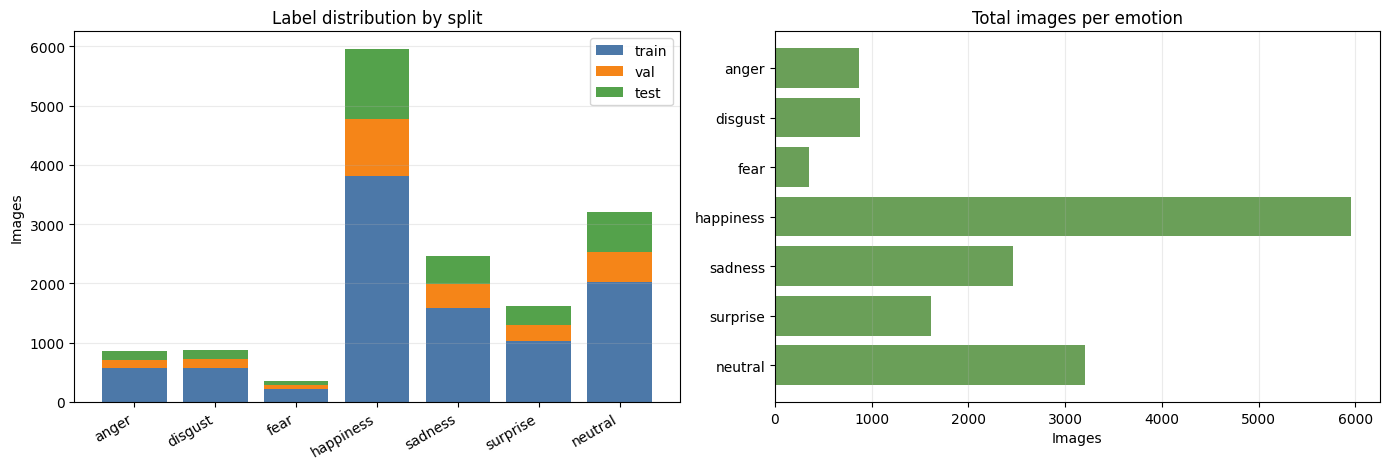

In [ ]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

CANONICAL_ORDER = ['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise', 'neutral']
emotion_order = [emotion for emotion in CANONICAL_ORDER if any(record['emotion'] == emotion for record in records)]
split_order = [split for split in ['train', 'val', 'test'] if any(record['split'] == split for record in records)]
split_emotion_counts = {
    split: Counter(record['emotion'] for record in records if record['split'] == split)
    for split in split_order
}
total_emotion_counts = Counter(record['emotion'] for record in records)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(emotion_order))
bottom = np.zeros(len(emotion_order), dtype=float)
colors = {'train': '#4c78a8', 'val': '#f58518', 'test': '#54a24b'}
for split in split_order:
    values = np.array([split_emotion_counts[split][emotion] for emotion in emotion_order], dtype=float)
    axes[0].bar(x, values, bottom=bottom, label=split, color=colors[split])
    bottom += values
axes[0].set_xticks(x, emotion_order, rotation=30, ha='right')
axes[0].set_ylabel('Images')
axes[0].set_title('Label distribution by split')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)

total_values = [total_emotion_counts[emotion] for emotion in emotion_order]
y = np.arange(len(emotion_order))
axes[1].barh(y, total_values, color='#6a9f58')
axes[1].set_yticks(y, emotion_order)
axes[1].invert_yaxis()
axes[1].set_xlabel('Images')
axes[1].set_title('Total images per emotion')
axes[1].grid(axis='x', alpha=0.25)
plt.tight_layout()
distribution_path = NOTEBOOK_VISUAL_STAGE_DIR / 'rafdb_train_distribution.png'
fig.savefig(distribution_path, dpi=180, bbox_inches='tight')
print('Staged:', distribution_path)
plt.show()


## 3.3. Preview ảnh mẫu


Staged: /home/jupyter-hault/EmotionCLIP-ReID/outputs/.notebook_staging/rafdb-20260720T223341.304582+0700-seed1234/visuals/rafdb_train_preview.png


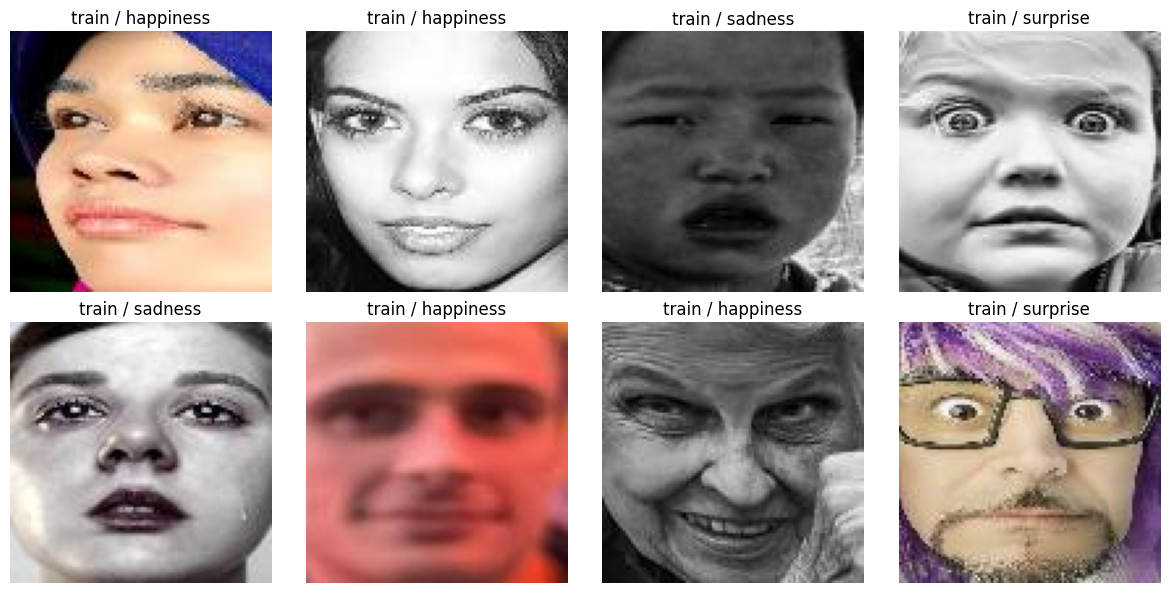

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

sample_records = [record for record in records if record['split'] == 'train'][:8]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.ravel():
    ax.axis('off')
for ax, record in zip(axes.ravel(), sample_records):
    image_path = RAF_ROOT / record['image_path']
    ax.imshow(Image.open(image_path).convert('RGB'))
    ax.set_title(f"{record['split']} / {record['emotion']}")
plt.tight_layout()
preview_path = NOTEBOOK_VISUAL_STAGE_DIR / 'rafdb_train_preview.png'
fig.savefig(preview_path, dpi=180, bbox_inches='tight')
print('Staged:', preview_path)
plt.show()


### 4.1 Gallery mẫu cân bằng theo lớp

Cell này lấy một ảnh đại diện cho mỗi emotion để kiểm tra nhanh đường dẫn ảnh và nhãn sau khi convert manifest.

Staged: /home/jupyter-hault/EmotionCLIP-ReID/outputs/.notebook_staging/rafdb-20260720T223341.304582+0700-seed1234/visuals/rafdb_train_balanced_gallery.png


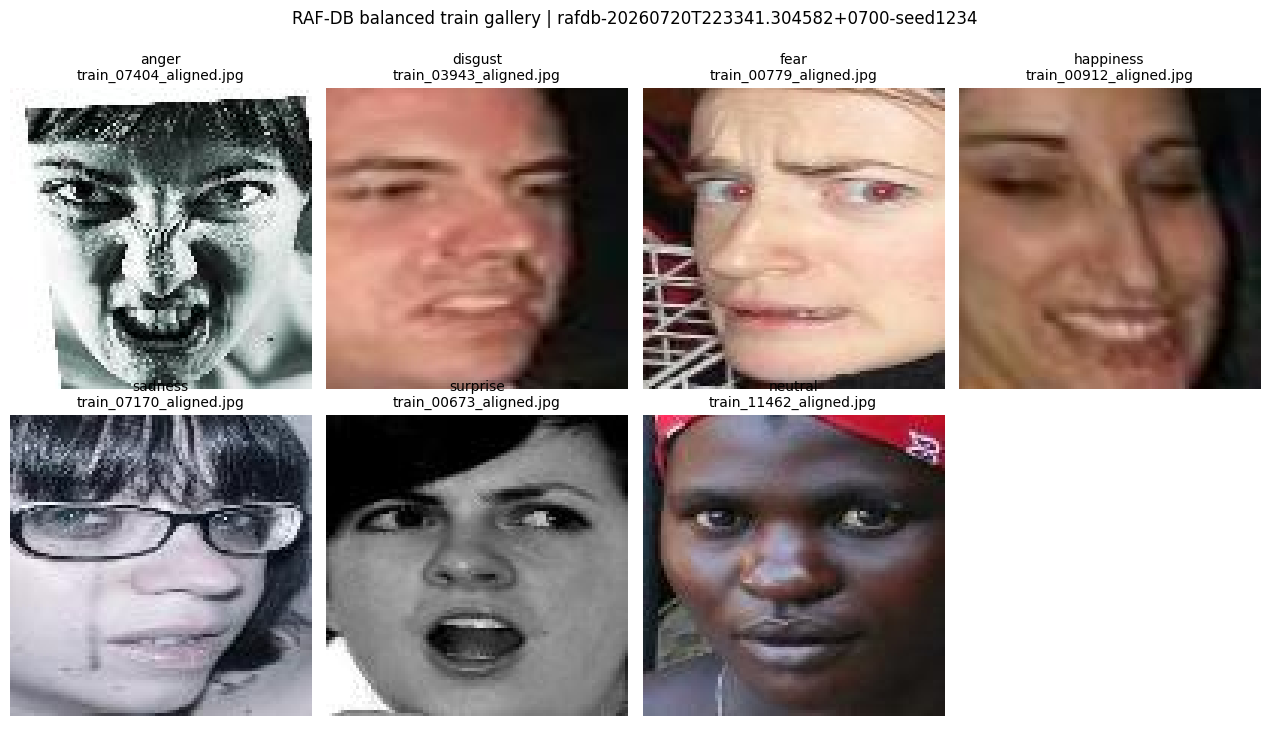

In [ ]:
import random
from collections import defaultdict
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

rng = random.Random(1234)
records_by_emotion = defaultdict(list)
for record in records:
    if record["split"] == "train":
        records_by_emotion[record["emotion"]].append(record)

sampled_records = []
for emotion in emotion_order:
    candidates = records_by_emotion.get(emotion, [])
    if candidates:
        sampled_records.append(rng.choice(candidates))

cols = min(4, max(1, len(sampled_records)))
rows = int(np.ceil(len(sampled_records) / cols)) if sampled_records else 1
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.6 * rows))
axes = np.atleast_1d(axes).ravel()
for ax in axes:
    ax.axis("off")

for ax, record in zip(axes, sampled_records):
    image_path = RAF_ROOT / record["image_path"]
    ax.imshow(Image.open(image_path).convert("RGB"))
    ax.set_title(f"{record['emotion']}\n{Path(record['image_path']).name}", fontsize=10)
    ax.axis("off")
fig.suptitle(f'RAF-DB balanced train gallery | {RUN_ID}', y=1.01)
plt.tight_layout()
gallery_path = NOTEBOOK_VISUAL_STAGE_DIR / 'rafdb_train_balanced_gallery.png'
fig.savefig(gallery_path, dpi=180, bbox_inches='tight')
print('Staged:', gallery_path)
plt.show()


## 5. Train RAF-DB

Chỉnh GPU, epoch, batch size, learning rate, worker, pin-memory và công tắc Stage 1/2 trong cell cấu hình phía trên. Cell đó dựng `TRAIN_OVERRIDES`, nạp lại config và in `Resolved Stage 1/2` để xác nhận chính xác giá trị sẽ truyền vào training.

In [ ]:
import os
import subprocess
import sys
from datetime import datetime

from utils.notebook_progress import stream_process_output
from utils.notebook_run import publish_notebook_artifacts

train_cmd = [
    sys.executable, '-u', 'train_emotionclip.py',
    '--gpus', ','.join(str(gpu_id) for gpu_id in GPU_IDS),
    '--run-id', RUN_ID,
    '--config_file', str(RAF_CONFIG),
    *TRAIN_OVERRIDES,
]
env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'
env['EMOTIONCLIP_PROGRESS'] = '1'
env.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
print('RUN_ID:', RUN_ID)
print('Running:', ' '.join(train_cmd), flush=True)
process = subprocess.Popen(
    train_cmd, cwd=REPO, env=env,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
log_chunks = stream_process_output(process)
return_code = process.wait()
RUN_FINISHED_AT = datetime.now().astimezone()

if OUTPUT_DIR.is_dir() and (OUTPUT_DIR / 'provenance.json').is_file():
    notebook_payload = publish_notebook_artifacts(
        OUTPUT_DIR,
        NOTEBOOK_STAGING_DIR,
        console_text=''.join(log_chunks),
        metadata={
            'run_id': RUN_ID,
            'started_at': RUN_STARTED_AT.isoformat(),
            'finished_at': RUN_FINISHED_AT.isoformat(),
            'return_code': return_code,
            'command': train_cmd,
            'manifest': str(ACTIVE_MANIFEST),
        },
    )
    print('Notebook artifacts:', notebook_payload['output_dir'])
else:
    failed_log = NOTEBOOK_STAGING_DIR / 'notebook_console_failed.log'
    failed_log.write_text(''.join(log_chunks), encoding='utf-8')
    print('Run chưa khởi tạo OUTPUT_DIR; console được giữ tại:', failed_log)

if return_code != 0:
    print('\\n'.join(''.join(log_chunks).splitlines()[-80:]))
    raise subprocess.CalledProcessError(return_code, train_cmd)
print('Training finished:', OUTPUT_DIR)


## 6. Xem metrics tốt nhất hoặc epoch mới nhất

In [ ]:
from utils.notebook_metrics import load_validation_metrics, print_validation_summary

RUN_VISUAL_DIR = OUTPUT_DIR / 'visuals'
RUN_VISUAL_DIR.mkdir(parents=True, exist_ok=True)
validation_metrics = load_validation_metrics(candidate_output_dirs=[OUTPUT_DIR])
RESULT_DIR = validation_metrics['result_dir']
metric_files = validation_metrics['metric_files']
metric_history = validation_metrics['metric_history']
metrics_by_epoch = validation_metrics['metrics_by_epoch']
metrics_latest = validation_metrics['metrics_latest']
metrics_best = validation_metrics['metrics_best']
best_metric = validation_metrics['best_metric']
print('RUN_ID:', RUN_ID)
print_validation_summary(validation_metrics)


### 6.1 Biểu đồ metric validation theo epoch

Cell này gom `metrics_epoch_*.json` thành training dynamics của validation/test split.

In [ ]:
from utils.notebook_metrics import plot_validation_metric_curves

validation_visuals = dict(validation_metrics)
validation_visuals['result_dir'] = RUN_VISUAL_DIR
plot_validation_metric_curves(validation_visuals, dataset_name='RAF-DB', file_prefix='rafdb')


### 6.2 Biểu đồ loss/accuracy training từ log

Cell này chỉ parse log/CSV nằm trong `OUTPUT_DIR` của `RUN_ID` hiện tại; không đọc report hoặc thư mục output dùng chung.

In [ ]:
from utils.notebook_metrics import load_training_history, plot_training_metric_curves

training_history, training_source = load_training_history(
    [OUTPUT_DIR], csv_candidates=[OUTPUT_DIR / 'training_epoch_losses.csv']
)
plot_training_metric_curves(
    training_history, training_source, RUN_VISUAL_DIR, file_prefix='rafdb'
)


### 6.3 Confusion matrix và per-class F1

Cell này dùng epoch mới nhất đang được chọn trong `metrics_latest`. Chạy lại cell metrics phía trên nếu muốn đổi thư mục/epoch.

In [ ]:
from utils.notebook_metrics import plot_confusion_matrix_and_f1

plot_confusion_matrix_and_f1(
    validation_visuals, dataset_name='RAF-DB', file_prefix='rafdb'
)


## 7. Infer một ảnh validation

In [ ]:
import json
import subprocess
import sys

from PIL import Image
import matplotlib.pyplot as plt

result_dir = OUTPUT_DIR
eval_records = [record for record in records if record['split'] == 'val']
if not eval_records:
    raise RuntimeError('RAF-DB manifest không có validation split')
sample = eval_records[0]
weight = OUTPUT_DIR / 'best_emotionclip.pth'
image_path = RAF_ROOT / sample['image_path']
assert weight.is_file(), f'Không thấy checkpoint trong run {RUN_ID}: {weight}'

print('Ground truth:', sample['emotion'])
print('Image:', image_path)
print('Weight:', weight)
completed = subprocess.run(
    [
        sys.executable, 'infer_emotionclip.py',
        '--config_file', str(RAF_CONFIG),
        '--weight', str(weight),
        '--image', str(image_path),
    ],
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    check=True,
)
print(completed.stdout)
json_start = completed.stdout.find('{')
result = json.loads(completed.stdout[json_start:]) if json_start >= 0 else {}
probabilities = result.get('probabilities', {})
names = list(probabilities.keys())
values = [probabilities[name] for name in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [1.0, 1.35]})
axes[0].imshow(Image.open(image_path).convert('RGB'))
axes[0].set_title(
    f"GT: {sample['emotion']}\nPred: {result.get('emotion')} | U={result.get('uncertainty', 0):.3f}"
)
axes[0].axis('off')
y = range(len(names))
colors = ['#2e7d32' if name == result.get('emotion') else '#607d8b' for name in names]
axes[1].barh(y, values, color=colors)
axes[1].set_yticks(list(y), names)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Probability')
axes[1].set_title('Inference probabilities')
axes[1].invert_yaxis()
plt.tight_layout()
infer_path = RUN_VISUAL_DIR / 'rafdb_inference_example.png'
fig.savefig(infer_path, dpi=180, bbox_inches='tight')
print('Saved:', infer_path)
plt.show()
